In [2]:
!pip install gdown ultralytics


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Downloading The Final Dataset

In [29]:
ID = "1APjRCMk1Y6TZ__n4sVig1hVUt-POj2R2"

In [30]:
!gdown --id {ID}

/home/vanadzor-npua/jupyter/venv/lib/python3.12/site-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1APjRCMk1Y6TZ__n4sVig1hVUt-POj2R2
From (redirected): https://drive.google.com/uc?id=1APjRCMk1Y6TZ__n4sVig1hVUt-POj2R2&confirm=t&uuid=bc72cb9e-31e3-45b0-b301-1195fde4edef
To: /home/vanadzor-npua/notebooks/yerevan190/rarrr/final_dataset.zip
100%|██████████████████████████████████████| 2.78G/2.78G [02:08<00:00, 21.7MB/s]


In [31]:
!unzip final_dataset.zip &> /dev/null # Redirecting stdout & stderr to /dev/null to suppress verbose output from unzip

In [32]:
!mv content/dataset_final .
!rm -rf content

## Downloading Sentry AI

In [1]:
sentry_repo = "https://github.com/vardgeszakaryan/Sentry/archive/refs/heads/main.zip"

In [2]:
# Downloading
!wget {sentry_repo} -O main.zip

# Unzipping
!unzip main.zip

--2026-03-01 14:32:13--  https://github.com/vardgeszakaryan/Sentry/archive/refs/heads/main.zip
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/vardgeszakaryan/Sentry/zip/refs/heads/main [following]
--2026-03-01 14:32:13--  https://codeload.github.com/vardgeszakaryan/Sentry/zip/refs/heads/main
Resolving codeload.github.com (codeload.github.com)... 140.82.121.9
Connecting to codeload.github.com (codeload.github.com)|140.82.121.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘main.zip’

main.zip                [ <=>                ]  46.86K  --.-KB/s    in 0.1s    

2026-03-01 14:32:14 (323 KB/s) - ‘main.zip’ saved [47981]

Archive:  main.zip
1ac3dab1638dc2443b6d0dc7143892a53de00ebf
   creating: Sentry-main/
  inflating: Sentry-main/.gitignore  
  inflating: Sentr

In [3]:
import sys
import os

# 1. Define the absolute path to the downloaded GitHub repository
# The unzipped folder is 'Sentry-main', so the path should reflect that.
repo_path = r"./Sentry-main/src"

# 2. Add it to sys.path so Python knows to look for modules there
if repo_path not in sys.path:
    sys.path.append(repo_path)

In [4]:
sys.path

['/usr/lib/python312.zip',
 '/usr/lib/python3.12',
 '/usr/lib/python3.12/lib-dynload',
 '',
 '/home/vanadzor-npua/jupyter/venv/lib/python3.12/site-packages',
 './Sentry-main/src']

## Dataset Analysis & Configuration

In [5]:
from pathlib import Path
import shutil
import os

In [6]:
# Initializing inner dataset directories to copy
dataset_dir = Path("dataset_final/processed")

merged_dataset = dataset_dir / "merged_datasets"
test_dataset = dataset_dir / "test_dataset" 

conf_file = Path("config/model_pipeline.yaml")

In [7]:
# Loading config file
from sentry_ai.config import load_config

configuration = load_config(conf_file)

In [10]:
from sentry_ai.analysis.dataset_analysis import analyze_dataset

analyze_dataset(merged_dataset, "./analyses")

Analyzing dataset from dataset_final/processed/merged_datasets...
Generating plots and saving to analyses
Analysis complete.


/home/vanadzor-npua/notebooks/yerevan190/rarrr/Sentry-main/src/sentry_ai/analysis/dataset_analysis.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories, y=cat_counts, palette="viridis")
/home/vanadzor-npua/notebooks/yerevan190/rarrr/Sentry-main/src/sentry_ai/analysis/dataset_analysis.py:148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=counts, palette="mako")


==================================analyses/class_distribution.png===================================


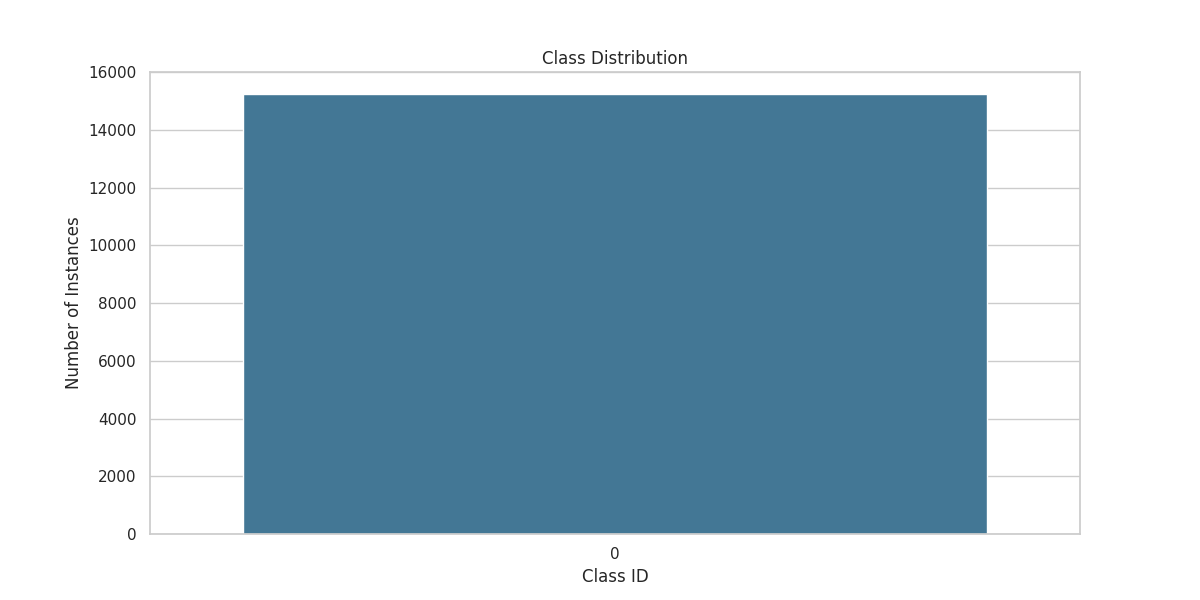

==================================analyses/box_centers_heatmap.png==================================


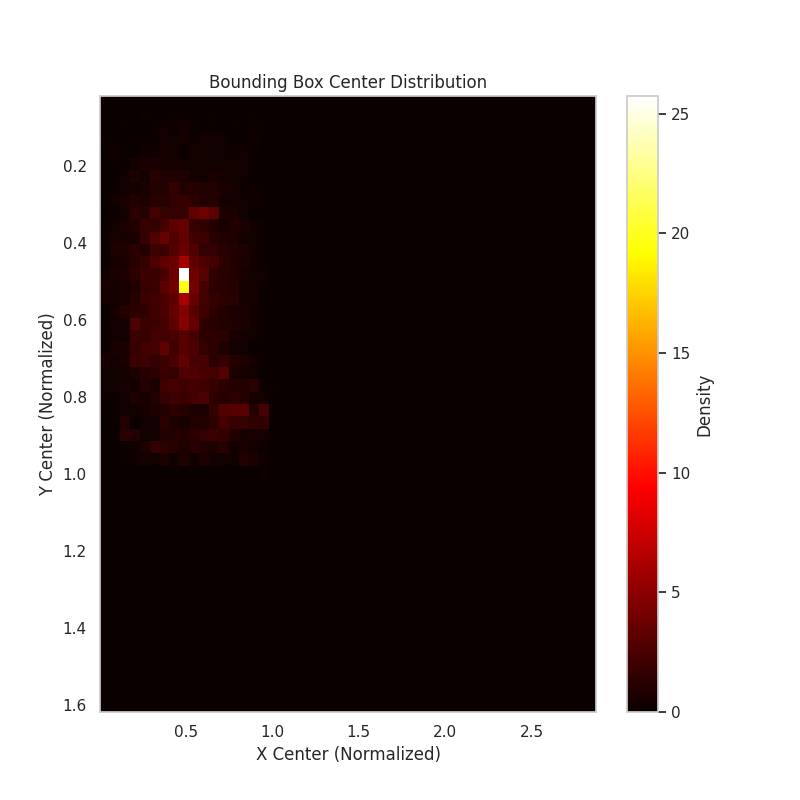

==================================analyses/box_size_categories.png==================================


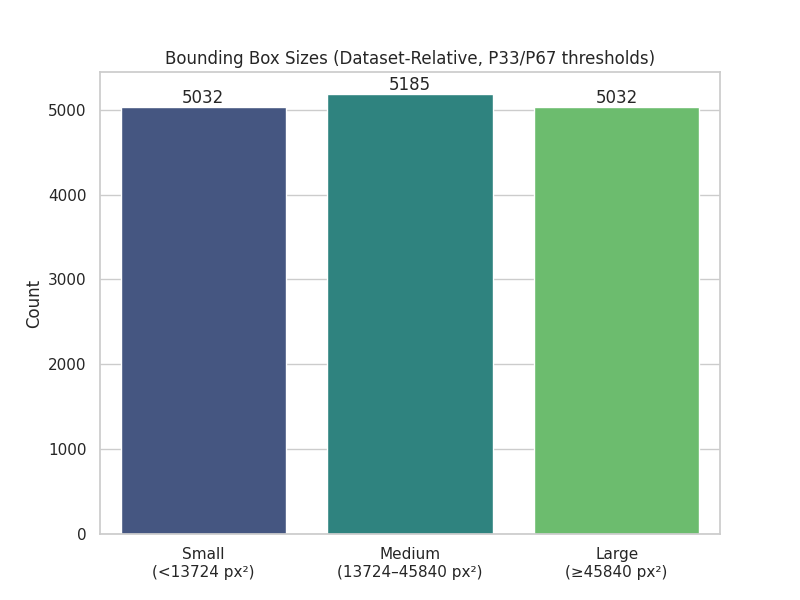

===================================analyses/analysis_summary.json===================================
{
    "total_images": 9762,
    "total_boxes": 15249,
    "class_counts": {
        "0": 15249
    },
    "box_size_thresholds": {
        "method": "percentile_33_67",
        "small_upper_px2": 13723.77,
        "medium_upper_px2": 45840.47
    },
    "box_size_stats": {
        "small": 5032,
        "medium": 5185,
        "large": 5032
    }
}
==================================analyses/image_sizes_scatter.png==================================


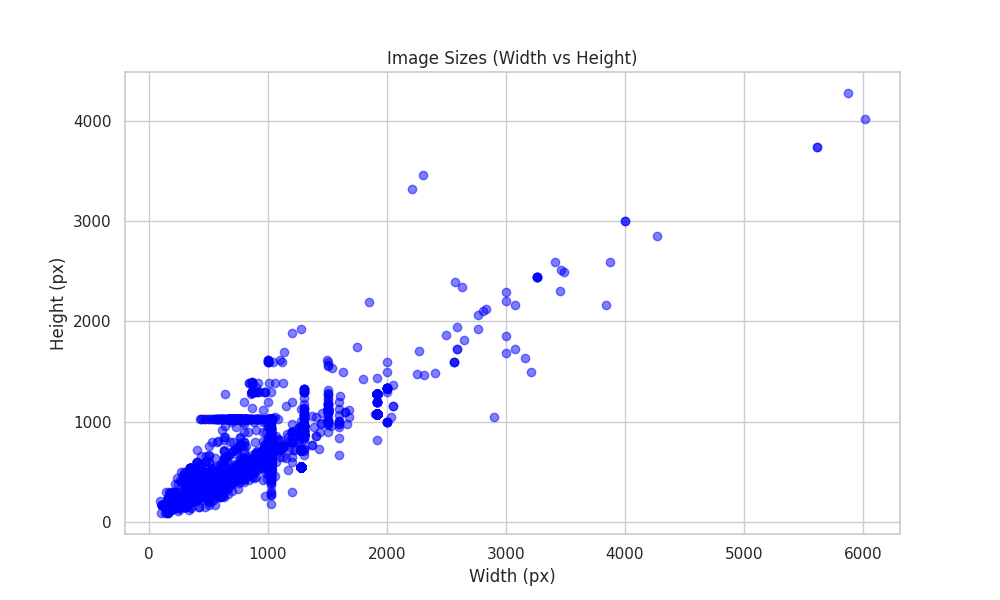

==================================analyses/box_sizes_relative.png===================================


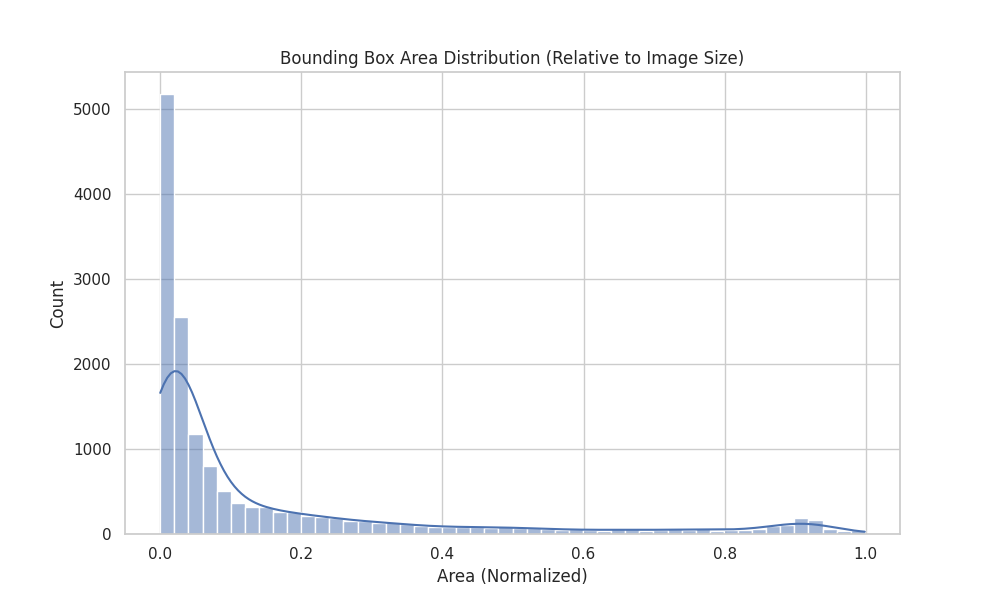

In [12]:
from IPython.display import display
from PIL import Image
import json

for file in Path("analyses").iterdir():
  print(f"{f'{file}':=^100}")

  if file.name.endswith("json"):
    print(json.dumps(
        json.load(file.open('r')),
        indent=4
        ))

  else:
    display(Image.open(file))

NameError: name 'image_folder' is not defined

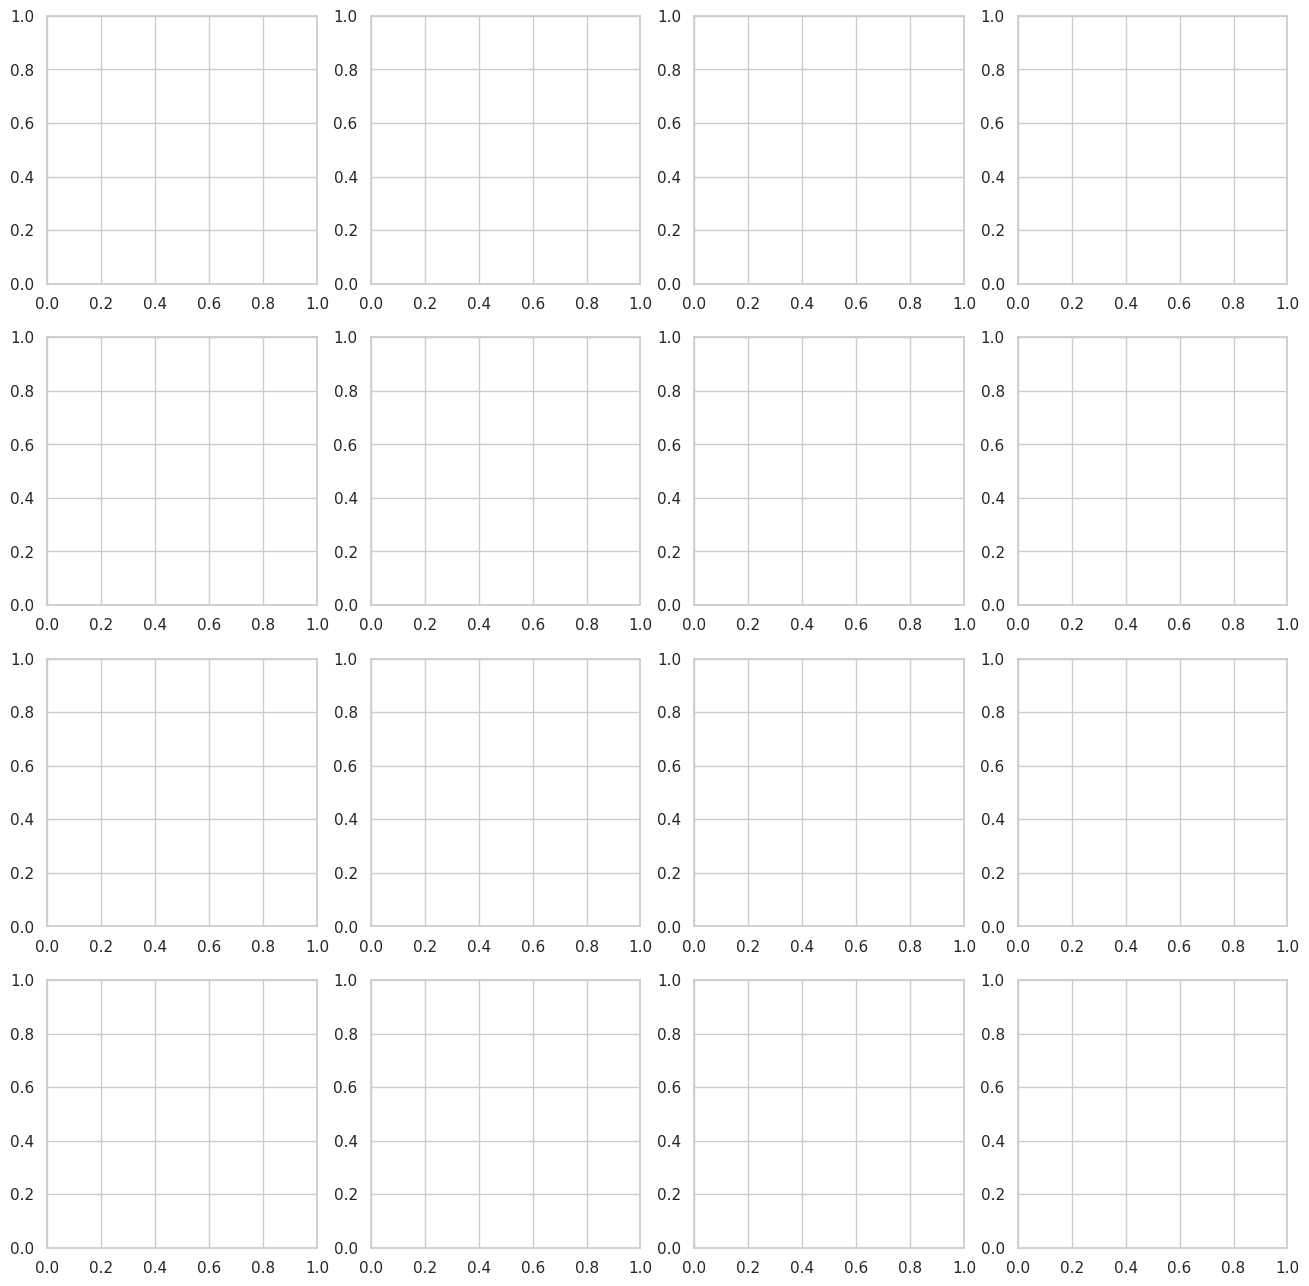

In [ ]:
# showing some images
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os
from pathlib import Path

image_folder = Path("dataset_final/processed/merged_datasets/images/train")
labels = Path("dataset_final/processed/merged_datasets/labels/train")

num_images = 16

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
img_files = os.listdir(image_folder)[555:555+num_images]

for i, ax in enumerate(axes.flat):
    if i < len(img_files):
            # Load Image
        img_path = os.path.join(image_folder, img_files[i])
        img = Image.open(img_path)
        w, h = img.size
        ax.imshow(img)

            # Load corresponding YOLO label (.txt)
        label_path = os.path.join(labels, img_files[i].replace('.jpg', '.txt'))
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    cls, x, y, nw, nh = map(float, line.split())
                        # Convert YOLO to Matplotlib Rect
                    rect = patches.Rectangle(
                        ((x - nw/2) * w, (y - nh/2) * h), 
                        nw * w, nh * h, 
                        linewidth=2, edgecolor='r', facecolor='none'
                    )
                    ax.add_patch(rect)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sentry_ai.yolo.train import train_yolo

train_yolo(config)